===== 去噪器相对误差对比 (Ratti P9-P13) =====
恒等映射 f=Id:   24.78%  (Ratti: 20.70%)
Tikhonov:        24.10%  (Ratti: 19.21%)
LASSO:           23.47%  (Ratti: 18.41%)
贝叶斯去噪器:     17.64%  (Ratti: 16.56%)


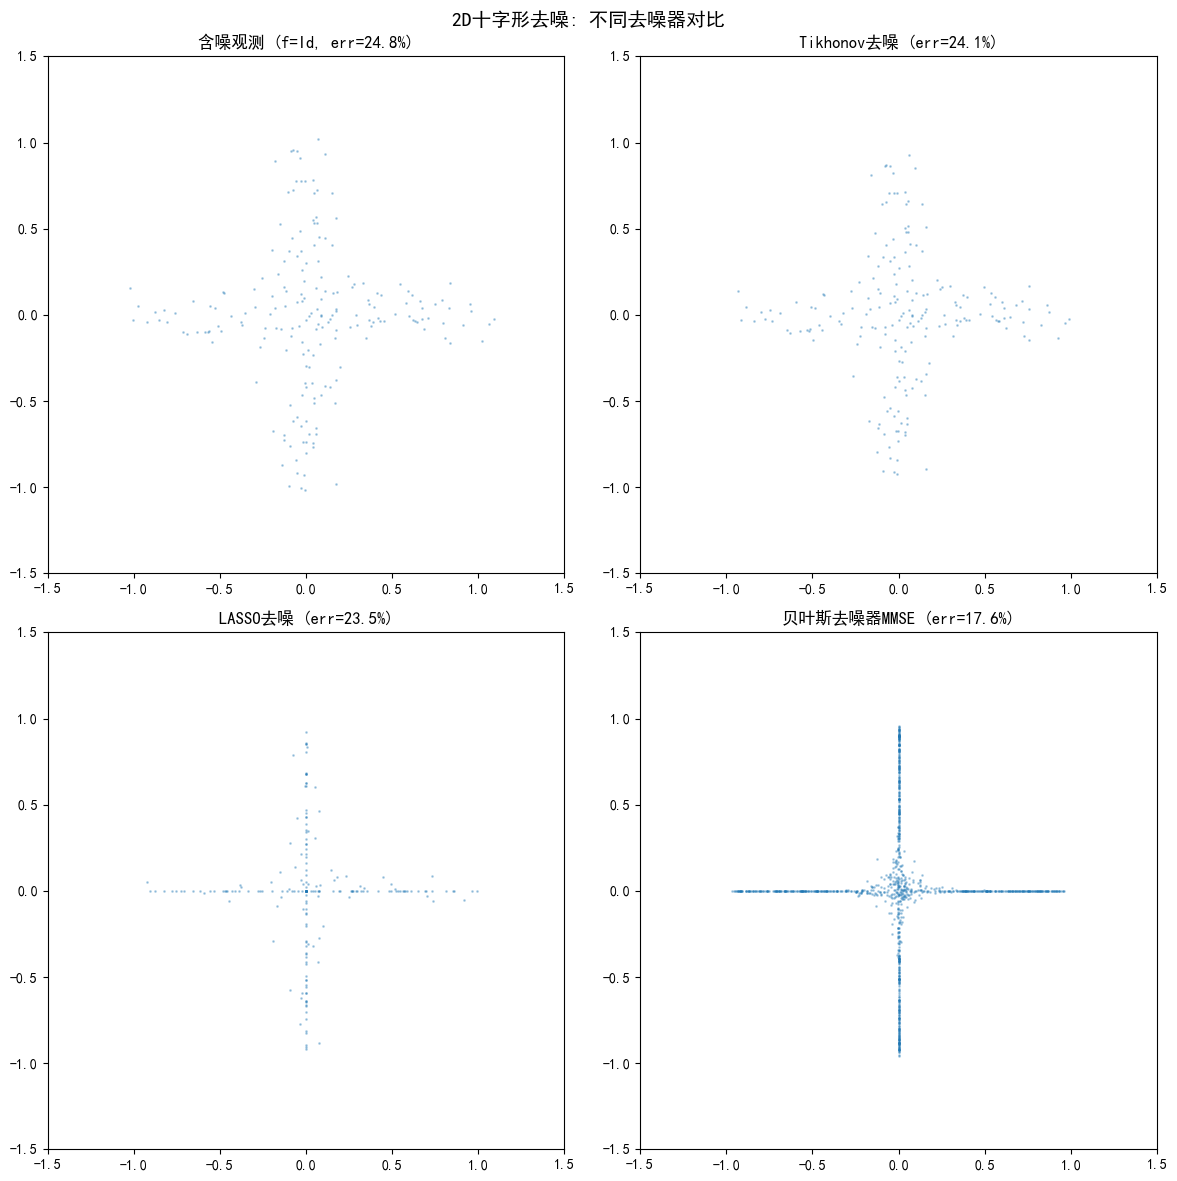

In [5]:
"""
实验2.7 十字形去噪器误差对比
对应章节：2.3 先验的质量：MMSE vs MAP估计器
知识点：MMSE估计器 = 贝叶斯去噪器；恒等映射 ≠ 最优去噪器；先验质量决定去噪器质量

素材来源：
  - Ratti Pre_course_II_Ratti.md P9-P13: 十字形去噪回归概念
    P10: f = Id, relative error: 20.70%
    P11: f_T = y/(1+lambda), relative error: 19.21%
    P12: f_L = ST(y; lambda), relative error: 18.41%
    P13: f_B = E[x|y], relative error: 16.56%
  - M1 CompImLab25.ipynb: soft_thresh 函数 + Tikhonov闭式解
"""

import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
# 1. 彻底屏蔽 matplotlib 的字体警告日志
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. 忽略 Python 层面的相关 UserWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")

# 3. 强制使用 ASCII 减号（连字符）替代 Unicode 减号（U+2212），并设置中文字体
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

np.random.seed(42)

# ====== 来源: Ratti P9-P13 (Pre_course_II_Ratti.md) ======
# 十字形分布: x 均匀分布在 {0}×[-1,1] ∪ [-1,1]×{0}
# y = x + ε, ε ~ N(0, 0.1² I)

#N = 50000
N = 1000
sigma_eps = 0.1  # Ratti P10: ε ~ N(0, 0.1² I)

# 生成十字形分布 (Ratti P10)
x = np.zeros((N, 2))
for i in range(N):
    if np.random.rand() < 0.5:
        x[i, 0] = 0.0
        x[i, 1] = np.random.uniform(-1, 1)
    else:
        x[i, 0] = np.random.uniform(-1, 1)
        x[i, 1] = 0.0

# 加噪 (Ratti P10: y = x + ε)
y = x + sigma_eps * np.random.randn(N, 2)

# ====== 四种去噪器 (Ratti P10-P13) ======

# 1) 恒等映射 (Ratti P10: f = Id, relative error: 20.70%)
x_identity = y
err_identity = np.sqrt(np.mean(np.sum((x_identity - x)**2, axis=1)) /
                       np.mean(np.sum(x**2, axis=1)))

# 2) Tikhonov 去噪器 (Ratti P11: f_T(y) = y/(1+λ))
lambda_tikh = 0.1
x_tikh = y / (1 + lambda_tikh)
err_tikh = np.sqrt(np.mean(np.sum((x_tikh - x)**2, axis=1)) /
                   np.mean(np.sum(x**2, axis=1)))

# 3) LASSO 去噪器 (Ratti P12: f_L(y) = ST(y; λ))
# M1: soft_thresh 函数
def soft_thresh(x, l):
    """软阈值函数 (来源: M1 CompImLab25.ipynb)"""
    return np.multiply(np.sign(x), np.maximum(np.abs(x) - l, np.zeros_like(x)))

lambda_lasso = 0.1
x_lasso = soft_thresh(y, lambda_lasso)
err_lasso = np.sqrt(np.mean(np.sum((x_lasso - x)**2, axis=1)) /
                    np.mean(np.sum(x**2, axis=1)))

# 4) 贝叶斯去噪器 (Ratti P13: f_B = E[x|y], MMSE估计器)
# 用蒙特卡罗近似: 对每个y，加权平均所有先验样本
#N_mc = 200000
N_mc = 2000
x_mc = np.zeros((N_mc, 2))
for i in range(N_mc):
    if np.random.rand() < 0.5:
        x_mc[i] = [0.0, np.random.uniform(-1, 1)]
    else:
        x_mc[i] = [np.random.uniform(-1, 1), 0.0]

N_test = min(5000, N)
x_bayes = np.zeros((N_test, 2))
for i in range(N_test):
    # 似然权重: w_j = exp(-||y_i - x_j||^2 / (2*sigma^2))
    diff = x_mc - y[i]
    log_w = -np.sum(diff**2, axis=1) / (2 * sigma_eps**2)
    log_w -= np.max(log_w)  # 数值稳定
    w = np.exp(log_w)
    w /= np.sum(w)
    x_bayes[i] = np.sum(w[:, np.newaxis] * x_mc, axis=0)

err_bayes = np.sqrt(np.mean(np.sum((x_bayes - x[:N_test])**2, axis=1)) /
                    np.mean(np.sum(x[:N_test]**2, axis=1)))

# 打印结果 (对应 Ratti P10-P13 的 relative error)
print("===== 去噪器相对误差对比 (Ratti P9-P13) =====")
print(f"恒等映射 f=Id:   {err_identity*100:.2f}%  (Ratti: 20.70%)")
print(f"Tikhonov:        {err_tikh*100:.2f}%  (Ratti: 19.21%)")
print(f"LASSO:           {err_lasso*100:.2f}%  (Ratti: 18.41%)")
print(f"贝叶斯去噪器:     {err_bayes*100:.2f}%  (Ratti: 16.56%)")

# ====== 可视化 ======
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

#idx = np.random.choice(N, 2000, replace=False)
idx = np.random.choice(N, 200, replace=False)
results = [
    (y[idx], f'含噪观测 (f=Id, err={err_identity*100:.1f}%)'),
    (x_tikh[idx], f'Tikhonov去噪 (err={err_tikh*100:.1f}%)'),
    (x_lasso[idx], f'LASSO去噪 (err={err_lasso*100:.1f}%)'),
    (x_bayes[:2000] if N_test >= 2000 else x_bayes,
     f'贝叶斯去噪器MMSE (err={err_bayes*100:.1f}%)')
]

for ax, (data, title) in zip(axes.flat, results):
    ax.scatter(data[:, 0], data[:, 1], s=1, alpha=0.3)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.set_title(title)

plt.suptitle('2D十字形去噪: 不同去噪器对比', fontsize=14)
plt.tight_layout()
plt.savefig('2_7_result.png', dpi=150, bbox_inches='tight')
plt.show()
